# Friction test

### Running it 

--- Loading and Compiling USDZAR ---
 Loaded 202511
 Loaded 202512
 Loaded 202601

--- Running Walk-Forward HMM to generate predictions ---
 Fold at index 0 processed.
 Fold at index 250 processed.
 Fold at index 500 processed.
 Fold at index 750 processed.
 Fold at index 1000 processed.
 Fold at index 1250 processed.
 Fold at index 1500 processed.
 Fold at index 1750 processed.
 Fold at index 2000 processed.
 Fold at index 2250 processed.
 Fold at index 2500 processed.
 Fold at index 2750 processed.
 Fold at index 3000 processed.

--- Executing Friction Test ---


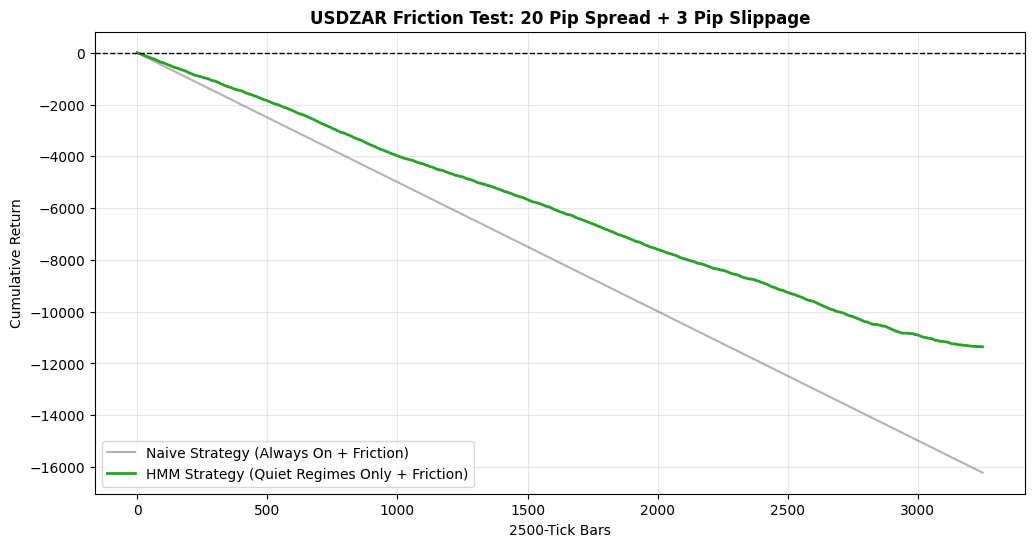

Final Naive Return: -16222.3055
Final HMM-Guided Return: -11355.5619

🏆 VERDICT: The Regime-Switching model successfully preserved capital by avoiding high-friction noise!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
PAIR = 'USDZAR'
MONTHS = ['202511', '202512', '202601']
TICK_WINDOW = 2500
TRAIN_BARS = 1000
TEST_BARS = 250
SPREAD_PIPS = 20
SLIPPAGE_PIPS = 3

def compile_data(pair, months):
    print(f"--- Loading and Compiling {pair} ---")
    bars_list = []
    for m in months:
        try:
            bid = pd.read_parquet(f"../data/processed/{pair.lower()}_dukascopy_bid_{m}.parquet")
            ask = pd.read_parquet(f"../data/processed/{pair.lower()}_dukascopy_ask_{m}.parquet")
            
            bid['datetime'] = pd.to_datetime(bid['datetime'])
            ask['datetime'] = pd.to_datetime(ask['datetime'])
            bid = bid.sort_values('datetime')
            ask = ask.sort_values('datetime')
            
            merged = pd.merge_asof(
                bid, 
                ask[['datetime', 'price']], 
                on='datetime', 
                direction='backward', 
                suffixes=('_bid', '_ask')
            )
            merged['mid_price'] = (merged['price_bid'] + merged['price_ask']) / 2
            
            # Sample every N ticks
            sampled = merged.iloc[::TICK_WINDOW].copy()
            bars_list.append(sampled)
            print(f" Loaded {m}")
        except Exception as e:
            print(f" Error loading {m}: {e}")
            
    df = pd.concat(bars_list).reset_index(drop=True)
    df['log_returns'] = np.log(df['mid_price'] / df['mid_price'].shift(1))
    df.dropna(inplace=True)
    df['vol_proxy'] = np.abs(df['log_returns']) * 1e6
    return df

# ==========================================
# 2. HMM PREDICTION GENERATION
# ==========================================
def generate_eval_data(df_bars):
    print("\n--- Running Walk-Forward HMM to generate predictions ---")
    eval_list = []
    start_idx = 0
    total_bars = len(df_bars)
    
    while (start_idx + TRAIN_BARS + TEST_BARS) <= total_bars:
        train_data = df_bars['vol_proxy'].iloc[start_idx : start_idx + TRAIN_BARS]
        test_data = df_bars['vol_proxy'].iloc[start_idx + TRAIN_BARS : start_idx + TRAIN_BARS + TEST_BARS]
        test_returns = df_bars['log_returns'].iloc[start_idx + TRAIN_BARS : start_idx + TRAIN_BARS + TEST_BARS]
        full_data = pd.concat([train_data, test_data])
        
        try:
            ms_model = sm.tsa.MarkovAutoregression(
                endog=full_data.values, 
                k_regimes=2, 
                order=1, 
                switching_ar=False, 
                switching_variance=True
            )
            ms_res = ms_model.fit(method='bfgs', disp=False)
            ms_forecast = ms_res.fittedvalues[-TEST_BARS:]
            
            eval_list.append(pd.DataFrame({
                'raw_returns': test_returns.values,
                'actual_vol': test_data.values,
                'pred_vol': ms_forecast
            }))
            print(f" Fold at index {start_idx} processed.")
        except:
            pass
            
        start_idx += TEST_BARS
        
    return pd.concat(eval_list, ignore_index=True)

# ==========================================
# 3. FRICTION TEST (YOUR LOGIC)
# ==========================================
def run_friction_test(df_eval, spread_pips=20, slippage_pips=3):
    print("\n--- Executing Friction Test ---")
    # --- 1. Define Friction Cost ---
    # USDZAR pip is 0.0001. Total cost per round turn = (Spread + 2 * Slippage)
    total_cost_per_trade = (spread_pips + (2 * slippage_pips)) * 0.0001
    
    # --- 2. Strategy A: Naive (Always On) ---
    # We subtract cost-to-vol ratio from every return
    naive_returns = df_eval['raw_returns'] - (total_cost_per_trade / (df_eval['actual_vol'].mean() / 1e6))
    naive_cum = np.cumsum(naive_returns)
    
    # --- 3. Strategy B: Regime-Aware (HMM Guided) ---
    # Logic: If predicted vol is in the top 30% (Regime 1), we sit out.
    vol_threshold = df_eval['pred_vol'].quantile(0.70)
    
    hmm_returns = np.where(
        df_eval['pred_vol'] < vol_threshold, 
        df_eval['raw_returns'] - (total_cost_per_trade / (df_eval['actual_vol'].mean() / 1e6)), 
        0
    )
    hmm_cum = np.cumsum(hmm_returns)
    
    # --- 4. Plotting ---
    plt.figure(figsize=(12, 6))
    plt.plot(naive_cum, label='Naive Strategy (Always On + Friction)', color='gray', alpha=0.6)
    plt.plot(hmm_cum, label='HMM Strategy (Quiet Regimes Only + Friction)', color='tab:green', linewidth=2)
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    
    plt.title(f'USDZAR Friction Test: {spread_pips} Pip Spread + {slippage_pips} Pip Slippage', fontweight='bold')
    plt.ylabel('Cumulative Return')
    plt.xlabel('2500-Tick Bars')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Final Verdict
    print(f"Final Naive Return: {naive_cum.iloc[-1]:.4f}")
    print(f"Final HMM-Guided Return: {hmm_cum[-1]:.4f}")
    
    if hmm_cum[-1] > naive_cum.iloc[-1]:
        print("\n🏆 VERDICT: The Regime-Switching model successfully preserved capital by avoiding high-friction noise!")
    else:
        print("\n❌ VERDICT: Friction is too high; even the HMM couldn't save the edge.")

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    # Step 1: Compile the raw ticks into bars
    df_usdzar_bars = compile_data(PAIR, MONTHS)
    
    # Step 2: Run walk-forward HMM to get out-of-sample predictions
    df_eval_usdzar = generate_eval_data(df_usdzar_bars)
    
    # Step 3: Run the friction test
    run_friction_test(df_eval_usdzar, spread_pips=SPREAD_PIPS, slippage_pips=SLIPPAGE_PIPS)